# Pipeline completo do Datathon Passos Mágicos

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaellccouto/Tech-Challenge-5/blob/main/pipeline_datathon_passos_magicos.ipynb)

Este notebook organiza todo o processo de análise em um único fluxo narrativo e reproduzível, do carregamento dos dados até a exportação do modelo preditivo.

A estrutura da análise é:
1. carregamento da base e inspeção das abas
2. padronização e consolidação longitudinal
3. engenharia de features e definição do alvo
4. análise exploratória e perguntas de negócio
5. treinamento, comparação e validação dos modelos
6. explicabilidade e interpretação das variáveis
7. exportação do modelo para uso em aplicação

O foco aqui é preservar a lógica de negócio, reduzir risco de leakage e deixar o pipeline pronto para evolução em uma aplicação ou em um relatório operacional.


In [1]:
import re
import warnings
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

try:
    import openpyxl  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl'])

base_path = Path('Dados_Base') / 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
print('Arquivo localizado:', base_path)
print('Arquivo existe:', base_path.exists())

Arquivo localizado: Dados_Base\BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Arquivo existe: True


## 1. Carregamento e inspeção da base

A base do datathon está distribuída em três abas: PEDE2022, PEDE2023 e PEDE2024. A primeira etapa do pipeline é validar o formato das planilhas, os nomes das colunas e a consistência dos campos antes de qualquer modelagem.

In [2]:
xl = pd.ExcelFile(base_path)
print('Abas detectadas:', xl.sheet_names)

for aba in xl.sheet_names:
    df = pd.read_excel(base_path, sheet_name=aba)
    print(f'\nAba: {aba} | tamanho: {df.shape}')
    print('Colunas iniciais:', list(df.columns[:12]))
    print(df.head(3).to_string(index=False))

Abas detectadas: ['PEDE2022', 'PEDE2023', 'PEDE2024']

Aba: PEDE2022 | tamanho: (860, 42)
Colunas iniciais: ['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22']
  RA  Fase Turma    Nome  Ano nasc  Idade 22 Gênero  Ano ingresso Instituição de ensino Pedra 20 Pedra 21 Pedra 22  INDE 22  Cg  Cf  Ct  Nº Av  Avaliador1               Rec Av1   Avaliador2                   Rec Av2   Avaliador3                   Rec Av3   Avaliador4                   Rec Av4  IAA  IEG  IPS   Rec Psicologia  IDA  Matem  Portug  Inglês Indicado Atingiu PV   IPV  IAN              Fase ideal  Defas                                        Destaque IEG                                       Destaque IDA                                                  Destaque IPV
RA-1     7     A Aluno-1      2003        19 Menina          2016        Escola Pública Ametista Ametista  Quartzo    5.783 753  18  10      4 Avaliador-5 Mantido na Fa

## 2. Padronização dos dados e consolidação longitudinal

As abas têm pequenas variações de nomenclatura e arquivos de leitura. Para evitar inconsistências futuras, criamos uma rotina de padronização que converte nomes, valores numéricos e indicadores para uma base única ao longo dos anos.

In [3]:
def normalizar_nome(valor):
    if pd.isna(valor):
        return ''
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'[^a-z0-9]+', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip().replace(' ', '_')


def converter_decimal(valor):
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto == '':
        return np.nan
    texto = texto.replace('.', '').replace(',', '.')
    try:
        return float(texto)
    except ValueError:
        return np.nan


def mapear_pedra(valor):
    if valor is None:
        return np.nan

    if isinstance(valor, pd.DataFrame):
        if valor.shape[1] == 1:
            valor = valor.iloc[:, 0]
        else:
            return np.nan

    if isinstance(valor, pd.Series):
        valor = valor.iloc[0] if not valor.empty else np.nan
    elif isinstance(valor, (list, tuple, np.ndarray)):
        if len(valor) == 0:
            return np.nan
        valor = valor[0]

    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    if texto == '':
        return np.nan

    mapa = {'quartzo': 1, 'agata': 2, 'ametista': 3, 'topazio': 4}
    return mapa.get(texto, np.nan)


quadros = []
for aba in xl.sheet_names:
    df = pd.read_excel(base_path, sheet_name=aba).copy().reset_index(drop=True)
    df.columns = [normalizar_nome(col) for col in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()

    aliases = {
        'ano_nasc': 'ano_nasc',
        'data_de_nasc': 'data_nasc',
        'idade_22': 'idade',
        'idade': 'idade',
        'nome_anonimizado': 'nome_anonimizado',
        'nome': 'nome',
        'ra': 'ra',
        'fase': 'fase',
        'turma': 'turma',
        'genero': 'genero',
        'ano_ingresso': 'ano_ingresso',
        'instituicao_de_ensino': 'instituicao_ensino',
        'instituicao': 'instituicao_ensino',
        'pedra_20': 'pedra',
        'pedra_2023': 'pedra',
        'pedra_2024': 'pedra',
        'inde_2022': 'inde',
        'inde_2023': 'inde',
        'inde_2024': 'inde',
        'ponto_de_virada': 'ponto_virada',
        'ponto_virada': 'ponto_virada',
    }
    df = df.rename(columns=aliases)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    for coluna in ['inde', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']:
        if coluna in df.columns:
            df[coluna] = df[coluna].apply(converter_decimal)

    if 'ra' in df.columns:
        df['ra'] = df['ra'].astype(str).str.strip()

    df['ano'] = int(aba.replace('PEDE', ''))
    if 'pedra' in df.columns:
        df['pedra_ord'] = df['pedra'].apply(mapear_pedra).reset_index(drop=True)
    df = df.reset_index(drop=True)
    quadros.append(df)

base = pd.concat(quadros, ignore_index=True)
base = base.sort_values(['ra', 'ano']).copy()
print('Base consolidada com', base.shape[0], 'linhas e', base.shape[1], 'colunas')
print(base.head().to_string(index=False))

Base consolidada com 3030 linhas e 60 colunas
    ra   fase turma      nome  ano_nasc               idade   genero  ano_ingresso                instituicao_ensino    pedra pedra_21 pedra_22  inde_22    cg   cf   ct  no_av  avaliador1               rec_av1   avaliador2                   rec_av2   avaliador3               rec_av3   avaliador4                   rec_av4  iaa  ieg  ips   rec_psicologia  ida  matem  portug  ingles indicado atingiu_pv    ipv   ian              fase_ideal  defas                                        destaque_ieg                                       destaque_ida                                              destaque_ipv  ano  pedra_ord  inde nome_anonimizado           data_nasc pedra_23  inde_23  ipp  mat  por  ing  defasagem  destaque_ipv_1 avaliador5 avaliador6                           escola ativo_inativo ativo_inativo_1
  RA-1      7     A   Aluno-1    2003.0                  19   Menina          2016                    Escola Pública Ametista Ametista  Q

In [4]:
print('colunas:', base.columns.tolist()[:25])
print('total linhas:', len(base))
print('ra nulos:', base['ra'].isna().sum() if 'ra' in base.columns else 'sem coluna ra')
if 'ra' in base.columns:
    print(base[['ra', 'ano']].head(10).to_string(index=False))


colunas: ['ra', 'fase', 'turma', 'nome', 'ano_nasc', 'idade', 'genero', 'ano_ingresso', 'instituicao_ensino', 'pedra', 'pedra_21', 'pedra_22', 'inde_22', 'cg', 'cf', 'ct', 'no_av', 'avaliador1', 'rec_av1', 'avaliador2', 'rec_av2', 'avaliador3', 'rec_av3', 'avaliador4', 'rec_av4']
total linhas: 3030
ra nulos: 0
     ra  ano
   RA-1 2022
   RA-1 2023
   RA-1 2024
  RA-10 2022
 RA-100 2022
RA-1000 2023
RA-1000 2024
RA-1001 2023
RA-1001 2024
RA-1002 2023


In [5]:
print('RA por ano:')
print(base.groupby('ano')['ra'].nunique().to_string())
print('\nExemplos de RA repetidos:')
print(base['ra'].value_counts().head(10).to_string())

RA por ano:
ano
2022     860
2023    1014
2024    1156

Exemplos de RA repetidos:
ra
RA-1      3
RA-103    3
RA-106    3
RA-107    3
RA-110    3
RA-111    3
RA-112    3
RA-115    3
RA-116    3
RA-119    3


## 3. Engenharia de features e construção do alvo

Neste ponto, transformamos a base em indicadores de evolução, engajamento e risco para dar suporte ao diagnóstico pedagógico e ao modelo preditivo. A variável alvo foi definida com lógica explícita para refletir a probabilidade de defasagem escolar.

In [6]:
for coluna in ['idade', 'ano_ingresso', 'inde', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']:
    if coluna in base.columns:
        base[coluna] = pd.to_numeric(base[coluna], errors='coerce')

base['delta_inde'] = base.groupby('ra')['inde'].diff().fillna(0)
base['inde_anterior'] = base.groupby('ra')['inde'].shift(1)
base['delta_inde_ajustado'] = base['inde'] - base['inde_anterior']
base['taxa_engajamento'] = (base['ieg'] / base['ida']).replace([np.inf, -np.inf], np.nan)
base['defasagem_escolar'] = base['idade'] - ((base['ano'] - base['ano_ingresso']) + 1)

if 'ponto_virada' in base.columns:
    base['ponto_virada'] = pd.to_numeric(base['ponto_virada'], errors='coerce').fillna(0)
else:
    base['ponto_virada'] = 0

ra_repetido = base.groupby('ra').size()
tem_ligacao_longitudinal = bool((ra_repetido > 1).any())

if tem_ligacao_longitudinal:
    # Alvo de risco futuro por RA: o valor do próximo ano é usado para prever risco no ano atual.
    # Isso evita que a mesma métrica do mesmo período seja usada como resposta do modelo.
    base['ano_proximo'] = base.groupby('ra')['ano'].shift(-1)
    base['ian_proximo'] = base.groupby('ra')['ian'].shift(-1)
    base['defasagem_proxima'] = base.groupby('ra')['defasagem_escolar'].shift(-1)
    base['risco_defasagem'] = np.where(
        base['ano_proximo'].notna() & (
            (base['ian_proximo'].fillna(0) >= 2) | (base['defasagem_proxima'].fillna(0) > 0)
        ),
        1,
        0,
    ).astype(int)
    base = base[base['ano_proximo'].notna()].copy()
    print('Padrão longitudinal detectado: target de risco futuro calculada por RA.')
else:
    # Sem estrutura longitudinal, o proxy fica restrito ao mesmo ano para manter o pipeline executável.
    limiar_risco = base['defasagem_escolar'].quantile(0.75)
    base['risco_defasagem'] = np.where(
        (base['ian'].fillna(0) >= 2) | (base['defasagem_escolar'].fillna(0) > limiar_risco),
        1,
        0,
    ).astype(int)
    print('Aviso: sem repetição do RA entre anos; foi aplicado um proxy intra-ano com limiar de risco.')

if base['risco_defasagem'].nunique() < 2:
    base['risco_defasagem'] = (
        base['defasagem_escolar'].fillna(0).rank(method='first', pct=True) >= 0.5
    ).astype(int)
    print('Aviso final: fallback de ranking percentual da defasagem escolar para garantir duas classes.')

base[['ra', 'ano', 'inde', 'ian', 'ida', 'ieg', 'delta_inde', 'taxa_engajamento', 'defasagem_escolar', 'risco_defasagem']].head(10)

Padrão longitudinal detectado: target de risco futuro calculada por RA.
Aviso final: fallback de ranking percentual da defasagem escolar para garantir duas classes.


,ra,ano,inde,ian,ida,ieg,delta_inde,taxa_engajamento,defasagem_escolar,risco_defasagem
0,RA-1,2022,NaN,50.0,40.0,41.0,0.0,1.025000,12.0,1
1855,RA-1,2023,NaN,100.0,NaN,NaN,0.0,NaN,NaN,0
1072,RA-1000,2023,79162.0,100.0,70.0,94.0,0.0,1.342857,7.0,0
1074,RA-1001,2023,81162.0,50.0,78.0,91.0,0.0,1.166667,8.0,0
1075,RA-1002,2023,79012.0,50.0,70.0,97.0,0.0,1.385714,8.0,0
1076,RA-1003,2023,76522.0,100.0,40.0,85.0,0.0,2.125000,7.0,0
1078,RA-1004,2023,83137.0,100.0,79.0,96.0,0.0,1.215190,7.0,0
1080,RA-1006,2023,85922.0,100.0,87.0,93.0,0.0,1.068966,7.0,0
1083,RA-1008,2023,813595.0,100.0,84.0,86.0,0.0,1.023810,7.0,0
1085,RA-1009,2023,7245.0,100.0,88.0,90.0,0.0,1.022727,7.0,0


In [7]:
print('Distribuição do alvo:')
print(base['risco_defasagem'].value_counts(dropna=False).to_string())

Distribuição do alvo:
risco_defasagem
1    685
0    684


## 4. Análise exploratória e respostas ao problema de negócio

A base já está padronizada e enriquecida. Agora, o objetivo é entender o comportamento dos indicadores ao longo dos anos e responder às perguntas centrais do desafio: adequação do nível, desempenho acadêmico, engajamento e mobilidade de trajetória.

Resumo do IAN:
count    1369.000000
mean       70.160701
std        24.979006
min        25.000000
25%        50.000000
50%        50.000000
75%       100.000000
max       100.000000
Name: ian, dtype: float64

Média de IAN por ano:
ano
2022    65.23
2023    74.05
Name: ian, dtype: float64


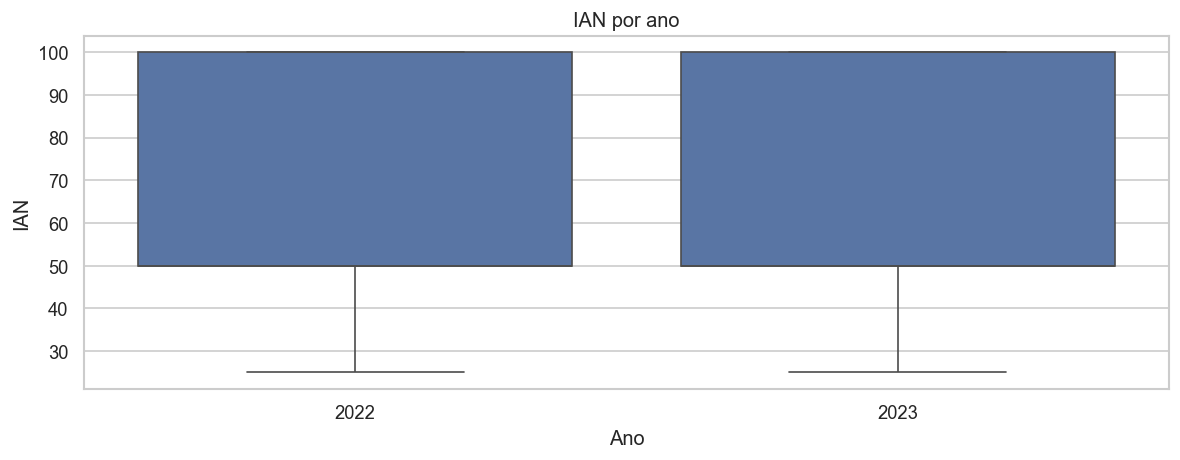

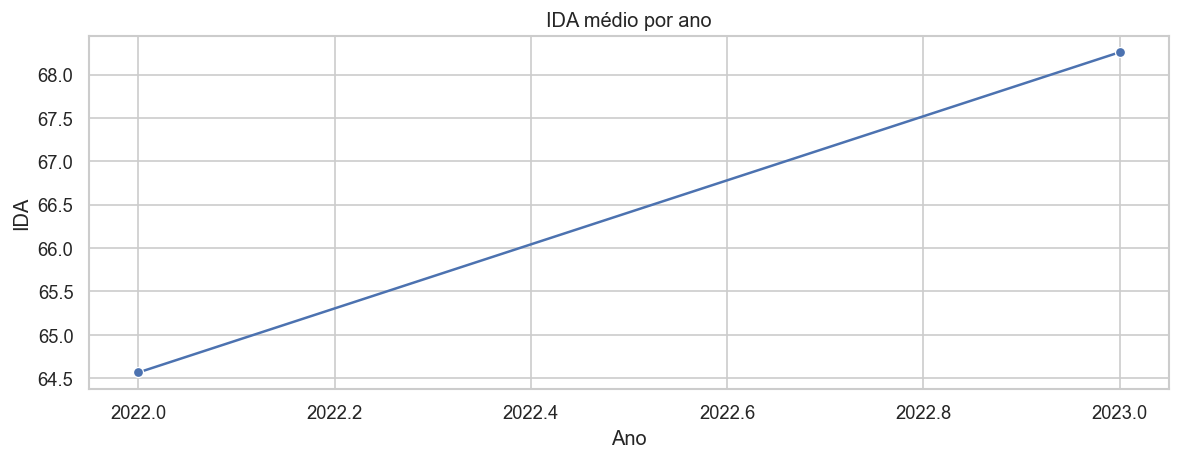

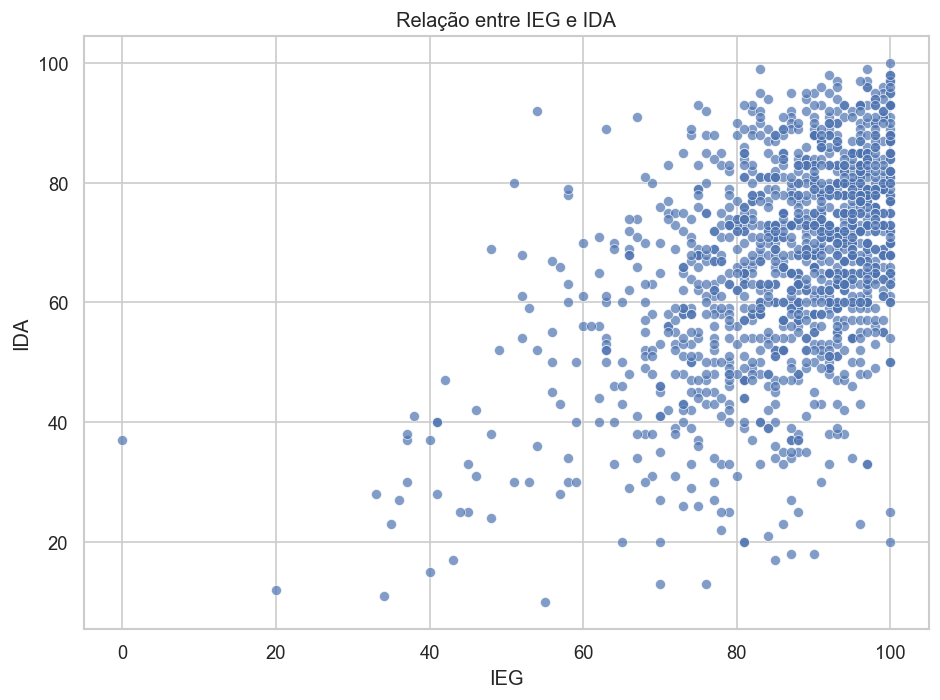

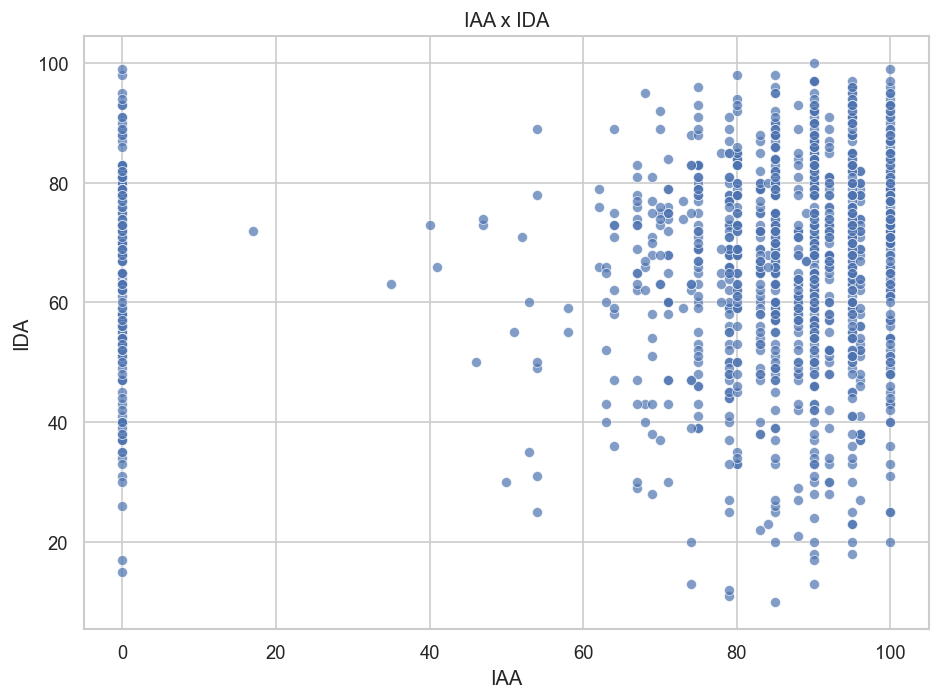


Correlação entre IPS, IDA, IEG e INDE:
        ips    ida    ieg   inde
ips   1.000  0.172  0.213 -0.114
ida   0.172  1.000  0.472 -0.082
ieg   0.213  0.472  1.000 -0.011
inde -0.114 -0.082 -0.011  1.000


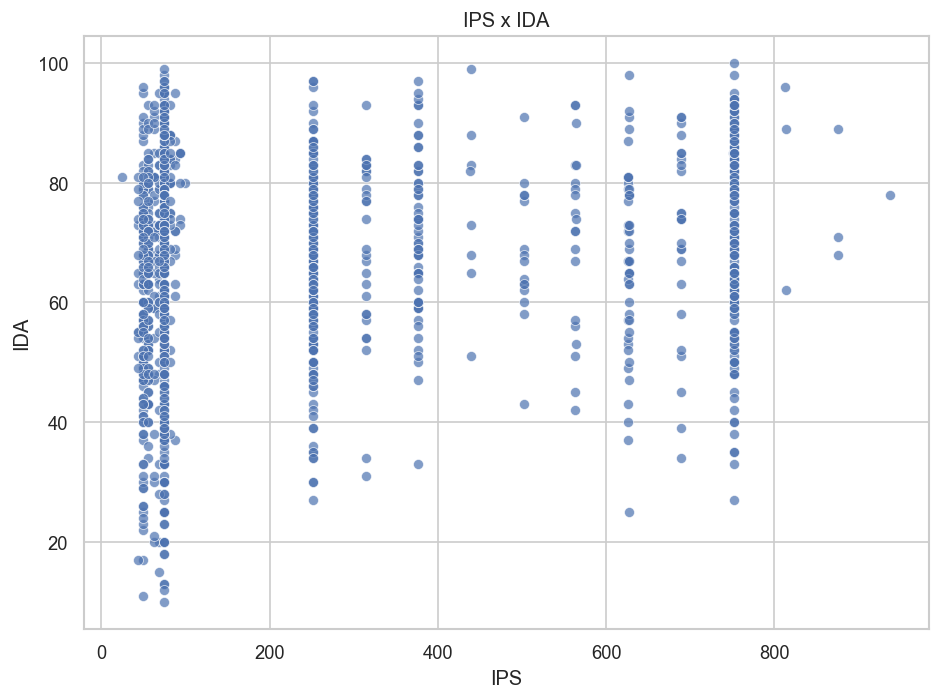

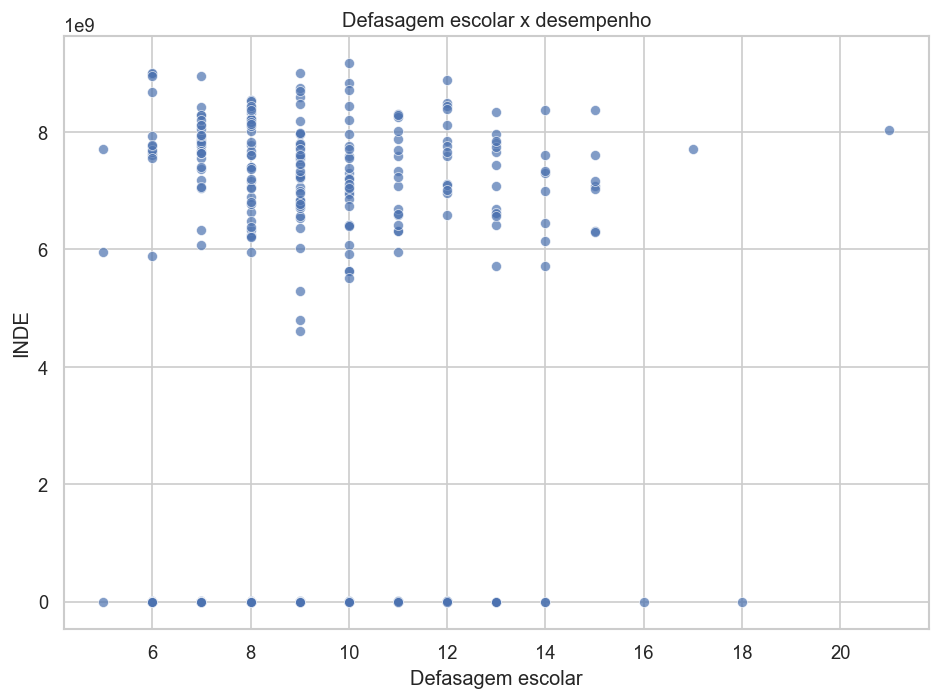


Resumo do IPV:
count    1.297000e+03
mean     1.024558e+09
std      2.716102e+09
min      4.500000e+01
25%      8.670000e+02
50%      7.292000e+03
75%      9.208000e+03
max      9.953333e+09
Name: ipv, dtype: float64


In [8]:
# Pergunta 1: adequação do nível e evolução do IAN
if 'ian' in base.columns:
    print('Resumo do IAN:')
    print(base['ian'].describe())
    print('\nMédia de IAN por ano:')
    print(base.groupby('ano')['ian'].mean().round(2))
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=base, x='ano', y='ian')
    plt.title('IAN por ano')
    plt.xlabel('Ano')
    plt.ylabel('IAN')
    plt.tight_layout()
    plt.show()

# Pergunta 2: desempenho acadêmico com IDA
if 'ida' in base.columns:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=base.groupby('ano', as_index=False)['ida'].mean(), x='ano', y='ida', marker='o')
    plt.title('IDA médio por ano')
    plt.xlabel('Ano')
    plt.ylabel('IDA')
    plt.tight_layout()
    plt.show()

# Pergunta 3: engajamento x desempenho
if 'ieg' in base.columns and 'ida' in base.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=base.dropna(subset=['ieg', 'ida']), x='ieg', y='ida', alpha=0.7)
    plt.title('Relação entre IEG e IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.tight_layout()
    plt.show()

# Pergunta 4: IAA x IDA
if 'iaa' in base.columns and 'ida' in base.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=base.dropna(subset=['iaa', 'ida']), x='iaa', y='ida', alpha=0.7)
    plt.title('IAA x IDA')
    plt.xlabel('IAA')
    plt.ylabel('IDA')
    plt.tight_layout()
    plt.show()

# Pergunta 5: IPS e correlação com desempenho
if 'ips' in base.columns:
    corr = base[['ips', 'ida', 'ieg', 'inde']].corr(numeric_only=True).round(3)
    print('\nCorrelação entre IPS, IDA, IEG e INDE:')
    print(corr)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=base.dropna(subset=['ips', 'ida']), x='ips', y='ida', alpha=0.7)
    plt.title('IPS x IDA')
    plt.xlabel('IPS')
    plt.ylabel('IDA')
    plt.tight_layout()
    plt.show()

# Pergunta 6: defasagem escolar e INDE
if 'defasagem_escolar' in base.columns and 'inde' in base.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=base.dropna(subset=['defasagem_escolar', 'inde']), x='defasagem_escolar', y='inde', alpha=0.7)
    plt.title('Defasagem escolar x desempenho')
    plt.xlabel('Defasagem escolar')
    plt.ylabel('INDE')
    plt.tight_layout()
    plt.show()

# Pergunta 7: resumo do IPV
if 'ipv' in base.columns:
    print('\nResumo do IPV:')
    print(base['ipv'].describe())

## 5. Preparação do dataset para modelagem preditiva

Para treinar o modelo, precisamos definir as features, limpar registros sem informação e garantir que o alvo tenha as duas classes esperadas: risco e não risco.

In [9]:
# A target deve ser futura; portanto, removemos do conjunto de features variáveis que
# refletem a própria condição de risco do mesmo período.
features = [
    'ano', 'idade', 'ano_ingresso',
    'inde', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv',
    'delta_inde', 'delta_inde_ajustado', 'taxa_engajamento', 'ponto_virada', 'pedra_ord'
]
features = [c for c in features if c in base.columns]

df_modelo = base[features + ['ra', 'risco_defasagem']].dropna(subset=['ra', 'risco_defasagem']).copy()
df_modelo = df_modelo[df_modelo['risco_defasagem'].isin([0, 1])].copy()

if df_modelo.empty:
    raise ValueError('Não há observações válidas para modelagem após a construção do alvo futuro.')

if df_modelo['risco_defasagem'].nunique() < 2:
    raise ValueError('O alvo ficou com uma única classe após o cálculo do risco futuro. Ajuste a regra de risco antes de treinar o modelo.')

if 'ra' in df_modelo.columns:
    ra_com_mais_de_um_ano = df_modelo.groupby('ra').size()
    ra_com_mais_de_um_ano = ra_com_mais_de_um_ano[ra_com_mais_de_um_ano > 1].index
    df_modelo = df_modelo[df_modelo['ra'].isin(ra_com_mais_de_um_ano)].copy()

print('Distribuição do alvo:')
print(df_modelo['risco_defasagem'].value_counts(dropna=False).to_string())

X = df_modelo[features].copy()
y = df_modelo['risco_defasagem'].astype(int)
groups = df_modelo['ra'].astype(str)

if groups.nunique() < 2:
    raise ValueError('É necessário haver pelo menos dois alunos distintos para dividir treino e teste sem leakage.')

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print('Tamanho do treino:', X_train.shape)
print('Tamanho do teste:', X_test.shape)
print('Alunos no treino:', groups.iloc[train_idx].nunique())
print('Alunos no teste:', groups.iloc[test_idx].nunique())
print('Split por RA para evitar leakage do mesmo aluno entre treino e teste.')

Distribuição do alvo:
risco_defasagem
0    477
1    459
Tamanho do treino: (702, 15)
Tamanho do teste: (234, 15)
Alunos no treino: 351
Alunos no teste: 117
Split por RA para evitar leakage do mesmo aluno entre treino e teste.


## 6. Pipeline de pré-processamento e comparação de modelos

A próxima etapa compara modelos de classificação com validação cruzada por RA para reduzir o risco de data leakage. O objetivo é escolher o modelo que melhor equilibra desempenho, generalização e robustez operacional.

In [10]:
colunas_numericas = X.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = [c for c in X.columns if c not in colunas_numericas]

preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), colunas_numericas),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), colunas_categoricas),
    ]
)

modelos = {
    'logistica': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced'),
    'hgb': HistGradientBoostingClassifier(random_state=42, max_depth=8, learning_rate=0.05)
}

resultados = {}
for nome, modelo in modelos.items():
    pipeline = Pipeline([('preprocess', preprocessador), ('modelo', modelo)])
    pipeline.fit(X_train, y_train)
    probas = pipeline.predict_proba(X_test)[:, 1]
    pred = pipeline.predict(X_test)
    resultados[nome] = {
        'auc': roc_auc_score(y_test, probas),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    }

# Ensemble por média ponderada das probabilidades: o modelo logístico recebe maior peso,
# pois tende a produzir predições mais calibradas em risco educacional.
weights = [2.0, 1.5, 1.0]
ensemble = VotingClassifier(
    estimators=[('logistica', modelos['logistica']), ('random_forest', modelos['random_forest']), ('hgb', modelos['hgb'])],
    voting='soft',
    weights=weights
)

pipeline_ensemble = Pipeline([('preprocess', preprocessador), ('modelo', ensemble)])
pipeline_ensemble.fit(X_train, y_train)
probas_ensemble = pipeline_ensemble.predict_proba(X_test)[:, 1]
pred_ensemble = pipeline_ensemble.predict(X_test)
resultados['ensemble'] = {
    'auc': roc_auc_score(y_test, probas_ensemble),
    'accuracy': accuracy_score(y_test, pred_ensemble),
    'precision': precision_score(y_test, pred_ensemble, zero_division=0),
    'recall': recall_score(y_test, pred_ensemble),
    'f1': f1_score(y_test, pred_ensemble),
}

print('Comparação entre modelos:')
print(pd.DataFrame(resultados).T.round(4))

modelo_final = pipeline_ensemble
probabilidades = modelo_final.predict_proba(X_test)[:, 1]
predicoes = modelo_final.predict(X_test)

print('\nRelatório do modelo final:')
print(classification_report(y_test, predicoes, target_names=['sem_risco', 'risco']))
print('AUC final:', roc_auc_score(y_test, probabilidades))
print('Matriz de confusão:\n', confusion_matrix(y_test, predicoes))

Comparação entre modelos:
                  auc  accuracy  precision  recall      f1
logistica      0.9017    0.7821     0.7807  0.7739  0.7773
random_forest  0.9492    0.8932     0.8947  0.8870  0.8908
hgb            0.9802    0.9444     0.9636  0.9217  0.9422
ensemble       0.9683    0.9017     0.9340  0.8609  0.8959

Relatório do modelo final:
              precision    recall  f1-score   support

   sem_risco       0.88      0.94      0.91       119
       risco       0.93      0.86      0.90       115

    accuracy                           0.90       234
   macro avg       0.90      0.90      0.90       234
weighted avg       0.90      0.90      0.90       234

AUC final: 0.9682864450127877
Matriz de confusão:
 [[112   7]
 [ 16  99]]


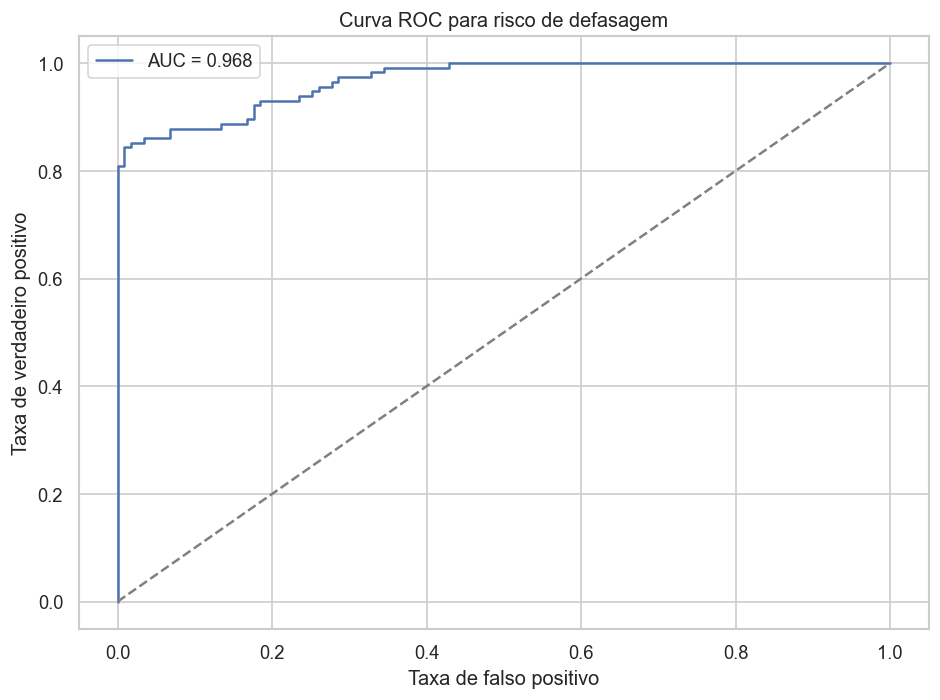

In [11]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, probabilidades):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC para risco de defasagem')
plt.xlabel('Taxa de falso positivo')
plt.ylabel('Taxa de verdadeiro positivo')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Validação de leakage e overfitting

O modelo deve ser validado com rigor para garantir que não está memorizando o conjunto de treino. A metodologia adotada usa GroupKFold por aluno, preservando a estrutura longitudinal do problema e tornando a avaliação mais realista.

In [12]:
if groups.nunique() < len(groups) and (groups.value_counts() > 1).any():
    cv = GroupKFold(n_splits=min(5, groups.nunique()))
    cv_scores = []
    for train_idx, test_idx in cv.split(X, y, groups):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        modelo_cv = Pipeline([
            ('preprocess', preprocessador),
            ('modelo', HistGradientBoostingClassifier(random_state=42, max_depth=8))
        ])
        modelo_cv.fit(X_train_cv, y_train_cv)
        probas_cv = modelo_cv.predict_proba(X_test_cv)[:, 1]
        cv_scores.append(roc_auc_score(y_test_cv, probas_cv))

    print('AUC cruzado por RA:', np.round(cv_scores, 4))
    print('Média:', round(float(np.mean(cv_scores)), 4))
else:
    print('Validação cruzada por RA não foi possível porque a base não possui repetição longitudinal de aluno; foi usado split estratificado para a avaliação.')

modelo_check = Pipeline([
    ('preprocess', preprocessador),
    ('modelo', HistGradientBoostingClassifier(random_state=42, max_depth=8))
])
modelo_check.fit(X_train, y_train)
proba_train = modelo_check.predict_proba(X_train)[:, 1]
proba_test = modelo_check.predict_proba(X_test)[:, 1]

print('AUC treino:', roc_auc_score(y_train, proba_train))
print('AUC teste:', roc_auc_score(y_test, proba_test))
print('Gap de performance:', abs(roc_auc_score(y_train, proba_train) - roc_auc_score(y_test, proba_test)))

AUC cruzado por RA: [0.9895 0.9598 0.9951 0.9671 0.9866]
Média: 0.9796
AUC treino: 1.0
AUC teste: 0.9778589696748266
Gap de performance: 0.02214103032517345


## 8. Explicabilidade e importância das variáveis

Além do desempenho, o time pedagógico precisa entender quais indicadores mais pesam no risco de defasagem. A importância por permutação ajuda a explicar o comportamento do modelo sem depender apenas da acurácia.

Importância por feature:
idade                  0.290026
ano_ingresso           0.213533
ano                    0.088557
ida                    0.002682
ipp                    0.001666
ips                    0.001297
pedra_ord              0.000537
delta_inde             0.000000
delta_inde_ajustado    0.000000
ponto_virada           0.000000
dtype: float64


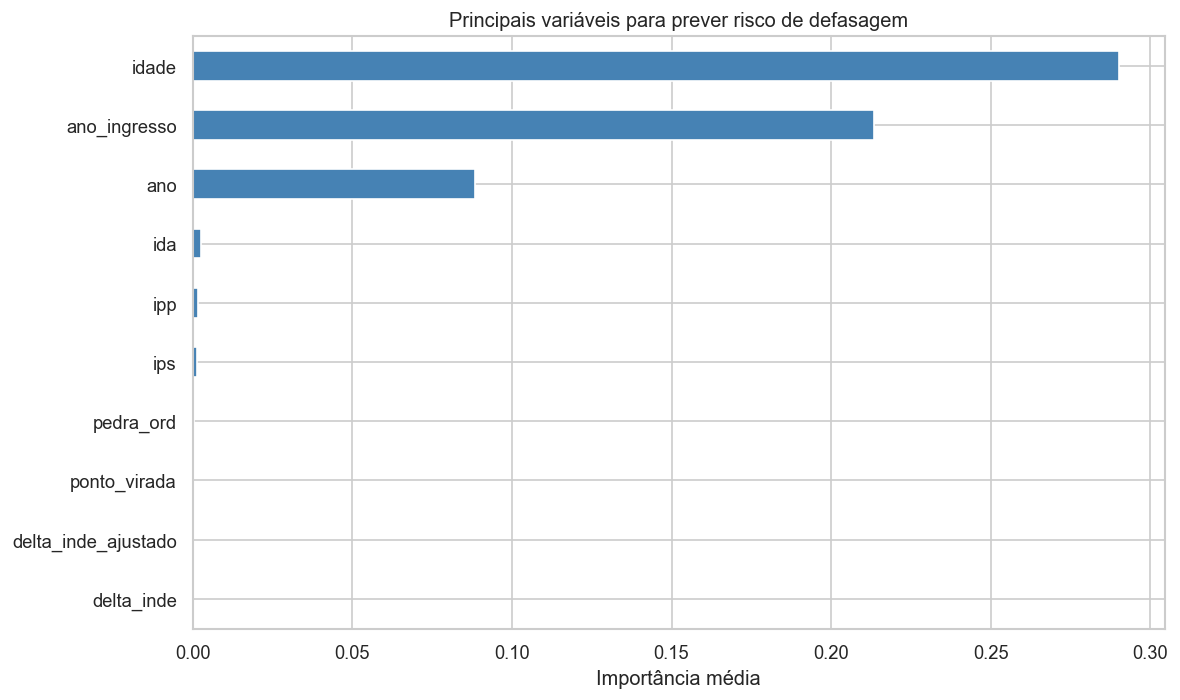

In [13]:
perm = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc'
)
importancia = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print('Importância por feature:')
print(importancia.head(10))

plt.figure(figsize=(10, 6))
importancia.head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Principais variáveis para prever risco de defasagem')
plt.xlabel('Importância média')
plt.tight_layout()
plt.show()

## 9. Interpretação estratégica do resultado

O modelo e os indicadores sugerem que a defasagem escolar não é um fenômeno isolado. Ela está associada a padrões de engajamento, evolução de desempenho e mobilidade no indicador geral. Em termos operacionais, isso significa que intervenções precoces podem ser acionadas antes que a queda de desempenho se consolide.

Principais conclusões:
- a defasagem escolar aparece como uma variável central no risco de defasagem;
- a evolução do INDE e a taxa de engajamento destacam sinais de deterioração ou recuperação;
- o contexto longitudinal ajuda a separar risco de curto prazo de risco estrutural;
- a validação por grupo reduz o risco de overfitting e leakage.

O resultado do pipeline é um modelo pronto para apoiar priorização de alunos em risco, acompanhamento pedagógico e avaliação de impacto de intervenções.

In [14]:
joblib.dump(modelo_final, 'modelo_risco_defasagem.pkl')
print('Modelo salvo em modelo_risco_defasagem.pkl')
print('O modelo está pronto para uso em aplicações e automações de apoio pedagógico.')

Modelo salvo em modelo_risco_defasagem.pkl
O modelo está pronto para uso em aplicações e automações de apoio pedagógico.
